# Are there differences in the Drivers of CDS Returns? Evidences from US and EU Markets

## Econometrics Project Group 4
This study aims to identify the main drivers of CDS-spread dynamics for a sample of major US and European banks. We examine how equity markets, yield-curve factors, financial uncertainty, and global risk conditions affect bank credit risk. The project also evaluates whether these variables can be used to forecast next-day movements in regional CDS indices through time-series forecasting models.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

from arch import arch_model
from linearmodels.panel import PanelOLS, RandomEffects
from scipy.stats import chi2
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)


In [64]:
treasury_columns = [
    "US1M", "US3M", "US6M", "US1Y", "US2Y", "US3Y",
    "US5Y", "US7Y", "US10Y", "US20Y", "US30Y",
]

yahoo_tickers = {
    "SP500": "^GSPC",
}


In [65]:
data = pd.read_csv("cds.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Ticker", "Date"])

cds_dates = data[["Date"]].drop_duplicates().sort_values("Date")
start_date = data["Date"].min().strftime("%Y-%m-%d")
end_date = (data["Date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

data[["Date", "Ticker", "Company", "PX5"]].head()


,Date,Ticker,Company,PX5
0,2015-01-01,A,Agilent Technologies Inc,86.3000
1,2015-01-02,A,Agilent Technologies Inc,86.4000
2,2015-01-05,A,Agilent Technologies Inc,88.2600
3,2015-01-06,A,Agilent Technologies Inc,91.1000
4,2015-01-07,A,Agilent Technologies Inc,92.5000


### GOLD, VIX
#### We collect data regarding VIX Index, Gold price for the selected dates

In [66]:
vix = pd.read_csv("vix_daily.csv")
vix["Date"] = pd.to_datetime(vix["Date"])
vix = vix[["Date", "close"]].rename(columns={"close": "VIX"})

gold_intraday = pd.read_csv("XAU_15m_data.csv", sep=";")
gold_intraday["DateTime"] = pd.to_datetime(
    gold_intraday["Date"],
    format="%Y.%m.%d %H:%M",
    errors="coerce",
)
gold_intraday["GOLD"] = pd.to_numeric(gold_intraday["Close"], errors="coerce")

gold = (
    gold_intraday
    .dropna(subset=["DateTime", "GOLD"])
    .assign(Date=lambda x: x["DateTime"].dt.normalize())
    .groupby("Date", as_index=False)
    .agg(GOLD=("GOLD", "last"))
)

local_macro = (
    cds_dates
    .merge(vix, on="Date", how="left")
    .merge(gold, on="Date", how="left")
    .sort_values("Date")
)

local_macro = local_macro.ffill().bfill()

local_macro

,Date,VIX,GOLD
0,2015-01-01,17.7900,1188.8200
1,2015-01-02,17.7900,1188.8200
2,2015-01-05,19.9200,1204.3200
3,2015-01-06,21.1200,1218.3500
4,2015-01-07,19.3100,1210.5200
...,...,...,...
1742,2021-09-06,16.4100,1823.1400
1743,2021-09-07,18.1400,1793.9200
1744,2021-09-08,17.9600,1789.2900
1745,2021-09-09,18.8000,1794.3600


### SP500
#### We collected via Yahoo Finance the SP500 values

In [67]:
sp500_raw = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=True, progress=False)

if isinstance(sp500_raw.columns, pd.MultiIndex):
    sp500_raw.columns = sp500_raw.columns.get_level_values(0)

sp500 = (
    sp500_raw[["Close"]]
    .reset_index()
    .rename(columns={"Close": "SP500"})
)

sp500["Date"] = pd.to_datetime(sp500["Date"]).dt.normalize()

sp500 = cds_dates.merge(sp500, on="Date", how="left")

sp500["SP500"] = sp500["SP500"].ffill().bfill()

sp500

,Date,SP500
0,2015-01-01,2058.2000
1,2015-01-02,2058.2000
2,2015-01-05,2020.5800
3,2015-01-06,2002.6100
4,2015-01-07,2025.9000
...,...,...
1742,2021-09-06,4535.4302
1743,2021-09-07,4520.0298
1744,2021-09-08,4514.0698
1745,2021-09-09,4493.2798


### EUROSTOXX
#### We collected via Yahoo Finance the EUROSTOXX values

In [68]:
eurostoxx_raw = yf.download("^STOXX50E", start=start_date, end=end_date, auto_adjust=True, progress=False)

if isinstance(eurostoxx_raw.columns, pd.MultiIndex):
    eurostoxx_raw.columns = eurostoxx_raw.columns.get_level_values(0)

eurostoxx = eurostoxx_raw[["Close"]].reset_index()

eurostoxx.columns = ["Date", "EUROSTOXX"]

eurostoxx["Date"] = pd.to_datetime(eurostoxx["Date"]).dt.normalize()

eurostoxx = cds_dates.merge(eurostoxx, on="Date", how="left")

eurostoxx["EUROSTOXX"] = eurostoxx["EUROSTOXX"].ffill().bfill()

eurostoxx

,Date,EUROSTOXX
0,2015-01-01,3023.1399
1,2015-01-02,3023.1399
2,2015-01-05,3023.1399
3,2015-01-06,3023.1399
4,2015-01-07,3026.7900
...,...,...
1742,2021-09-06,4246.1299
1743,2021-09-07,4225.0098
1744,2021-09-08,4177.1499
1745,2021-09-09,4177.1099


### RATES US
#### We perform a PCA on the US Treasury Yields to use them as regressors

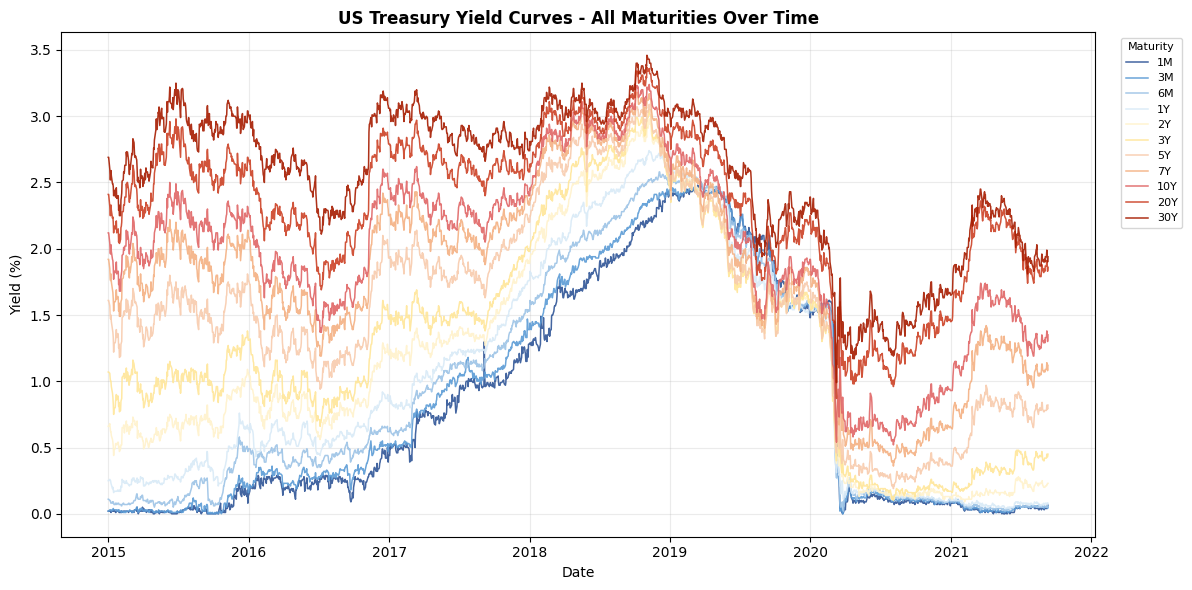

(           Date  rates_PC1  rates_PC2
 0    2015-01-01    -1.1775     1.6400
 1    2015-01-02    -1.1775     1.6400
 2    2015-01-05    -1.3437     1.4277
 3    2015-01-06    -1.5419     1.2524
 4    2015-01-07    -1.5914     1.2445
 ...         ...        ...        ...
 1742 2021-09-06    -3.3981    -0.0162
 1743 2021-09-07    -3.2722     0.0945
 1744 2021-09-08    -3.3426     0.0106
 1745 2021-09-09    -3.4364    -0.1028
 1746 2021-09-10    -3.3334    -0.0133
 
 [1747 rows x 3 columns],
           PC  explained_variance_ratio  cumulative_variance
 0  rates_PC1                    0.8423               0.8423
 1  rates_PC2                    0.1486               0.9909,
    corr_PC1_level  corr_PC2_slope
 0          0.9984          0.9252)

In [69]:
treasury = pd.read_csv("us_treasury_yields_daily.csv")
treasury["Date"] = pd.to_datetime(treasury["Date"])

treasury = treasury[["Date", *treasury_columns]]

treasury = (
    cds_dates
    .merge(treasury, on="Date", how="left")
    .sort_values("Date")
)

treasury[treasury_columns] = (
    treasury[treasury_columns]
    .replace([np.inf, -np.inf], np.nan)
    .ffill()
    .bfill()
)

treasury_colors = {
    "US1M": "#2f5597",
    "US3M": "#5b9bd5",
    "US6M": "#9dc3e6",
    "US1Y": "#d9eaf7",
    "US2Y": "#fff2cc",
    "US3Y": "#ffe699",
    "US5Y": "#f8cbad",
    "US7Y": "#f4b183",
    "US10Y": "#e06666",
    "US20Y": "#cc4125",
    "US30Y": "#a61c00",
}

treasury_labels = {
    "US1M": "1M",
    "US3M": "3M",
    "US6M": "6M",
    "US1Y": "1Y",
    "US2Y": "2Y",
    "US3Y": "3Y",
    "US5Y": "5Y",
    "US7Y": "7Y",
    "US10Y": "10Y",
    "US20Y": "20Y",
    "US30Y": "30Y",
}

fig, ax = plt.subplots(figsize=(12, 6))
for column in treasury_columns:
    ax.plot(
        treasury["Date"],
        treasury[column],
        label=treasury_labels[column],
        color=treasury_colors[column],
        linewidth=1.1,
        alpha=0.9,
    )

ax.set_title("US Treasury Yield Curves - All Maturities Over Time", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(True, alpha=0.25)
ax.legend(title="Maturity", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()

X = treasury[treasury_columns]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

rates_pc = pd.DataFrame({
    "Date": treasury["Date"].values,
    "rates_PC1": components[:, 0],
    "rates_PC2": components[:, 1],
})

explained_variance = pd.DataFrame({
    "PC": ["rates_PC1", "rates_PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

level_proxy = X.mean(axis=1)
slope_proxy = X["US30Y"] - X["US1M"]

pc_check = pd.DataFrame({
    "corr_PC1_level": [np.corrcoef(components[:, 0], level_proxy)[0, 1]],
    "corr_PC2_slope": [np.corrcoef(components[:, 1], slope_proxy)[0, 1]],
})

rates_pc, explained_variance, pc_check

### RATES EU
#### We derive from our custom dataset the rates in the EU and then we perform a PCA in an analogous way as before

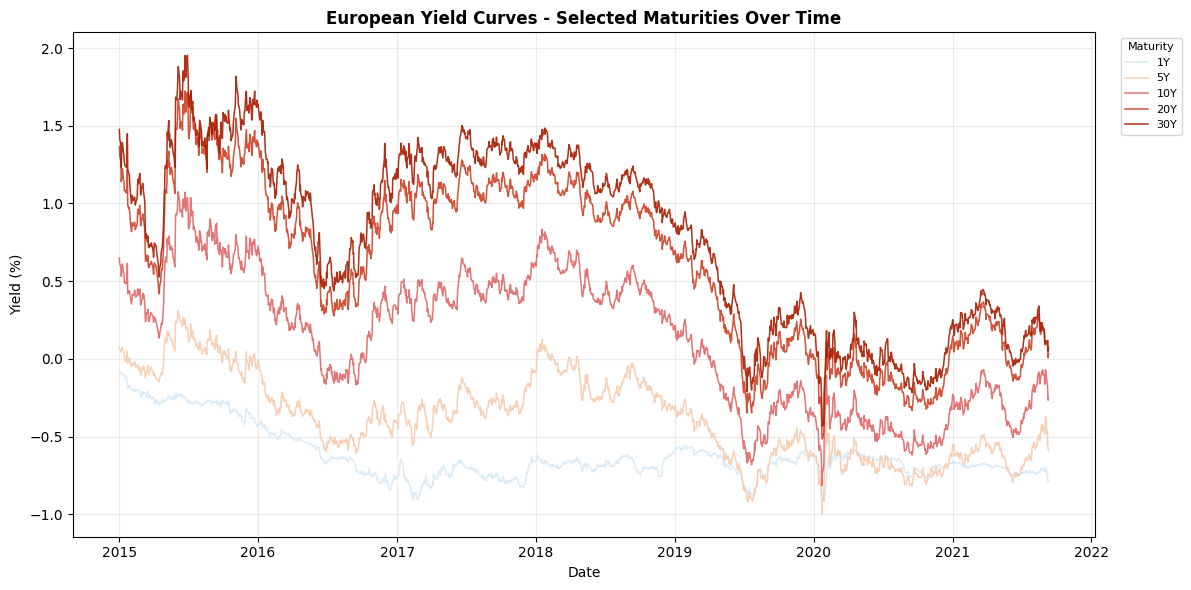

(      eu_rates_PC1  eu_rates_PC2
 0           3.5122       -2.2589
 1           3.3462       -2.3304
 2           3.2557       -2.3812
 3           2.9419       -2.5509
 4           3.0976       -2.4301
 ...            ...           ...
 1742       -1.7338        0.0804
 1743       -1.7238        0.0581
 1744       -2.0560        0.3568
 1745       -2.2788        0.2814
 1746       -2.2147        0.2815
 
 [1747 rows x 2 columns],
              PC  explained_variance_ratio  cumulative_variance
 0  eu_rates_PC1                    0.8285               0.8285
 1  eu_rates_PC2                    0.1581               0.9867,
    corr_PC1_level  corr_PC2_slope
 0          0.9968          0.5190)

In [70]:
eu_rates = pd.read_csv("Custom_ECB.csv")

curve_cols = ["1y", "5y", "10y", "20y", "30y"]

eu_rates = eu_rates[curve_cols].copy()

eu_rates = eu_rates.replace([np.inf, -np.inf], np.nan).ffill().bfill()

min_len = min(len(cds_dates), len(eu_rates))
eu_rates = eu_rates.iloc[:min_len].reset_index(drop=True)

eu_rates_plot = eu_rates.copy()
eu_rates_plot["Date"] = cds_dates["Date"].values[:len(eu_rates_plot)]

eu_rate_colors = {
    "1y": "#d9eaf7",
    "5y": "#f8cbad",
    "10y": "#e06666",
    "20y": "#cc4125",
    "30y": "#a61c00",
}

fig, ax = plt.subplots(figsize=(12, 6))
for column in curve_cols:
    ax.plot(
        eu_rates_plot["Date"],
        eu_rates_plot[column],
        label=column.upper(),
        color=eu_rate_colors[column],
        linewidth=1.1,
        alpha=0.9,
    )

ax.set_title("European Yield Curves - Selected Maturities Over Time", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(True, alpha=0.25)
ax.legend(title="Maturity", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()

X = eu_rates[curve_cols]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

level_proxy = X.mean(axis=1)
slope_proxy = X["10y"] - X["1y"]

if np.corrcoef(components[:, 1], slope_proxy)[0, 1] < 0:
    components[:, 1] *= -1

rates_eu_pc_data = pd.DataFrame({
    "eu_rates_PC1": components[:, 0],
    "eu_rates_PC2": components[:, 1],
})

rates_eu_pca_explained_variance = pd.DataFrame({
    "PC": ["eu_rates_PC1", "eu_rates_PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

pc_check_eu = pd.DataFrame({
    "corr_PC1_level": [np.corrcoef(components[:, 0], level_proxy)[0, 1]],
    "corr_PC2_slope": [np.corrcoef(components[:, 1], slope_proxy)[0, 1]],
})

rates_eu_pc_data, rates_eu_pca_explained_variance, pc_check_eu

In [71]:
banks_US = [
    "JPMorgan Chase   Co",
    "Bank of America Corp",
    "Citigroup Inc",
    "Goldman Sachs Group Inc The",
    "Wells Fargo   Co",
]

data = pd.read_csv("cds.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Ticker", "Date"])

cds_US_PX5 = (
    data[data["Company"].isin(banks_US)]
    [["Date", "Ticker", "Company", "PX5"]]
    .sort_values(["Company", "Date"])
    .reset_index(drop=True)
)

cds_US_PX5

,Date,Ticker,Company,PX5
0,2015-01-01,BAC,Bank of America Corp,67.7800
1,2015-01-02,BAC,Bank of America Corp,67.6300
2,2015-01-05,BAC,Bank of America Corp,70.1950
3,2015-01-06,BAC,Bank of America Corp,69.6700
4,2015-01-07,BAC,Bank of America Corp,68.7800
...,...,...,...,...
8730,2021-09-06,WFC,Wells Fargo Co,42.9102
8731,2021-09-07,WFC,Wells Fargo Co,42.9493
8732,2021-09-08,WFC,Wells Fargo Co,42.8433
8733,2021-09-09,WFC,Wells Fargo Co,42.4928


In [72]:
banks_EU = [
    "Banco Santander SA",
    "BNP Paribas SA",
    "Deutsche Bank AG",
    "Intesa Sanpaolo SpA",
    "UniCredit SpA",
    "Banco Bilbao Vizcaya Argentaria SA",
    "Barclays PLC",
]

data = pd.read_csv("cds.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Ticker", "Date"])

cds_EU_PX5 = (
    data[data["Company"].isin(banks_EU)]
    [["Date", "Ticker", "Company", "PX5"]]
    .sort_values(["Company", "Date"])
    .reset_index(drop=True)
)

cds_EU_PX5

,Date,Ticker,Company,PX5
0,2015-01-01,BNP,BNP Paribas SA,69.9050
1,2015-01-02,BNP,BNP Paribas SA,64.3000
2,2015-01-05,BNP,BNP Paribas SA,69.4200
3,2015-01-06,BNP,BNP Paribas SA,70.7150
4,2015-01-07,BNP,BNP Paribas SA,69.9850
...,...,...,...,...
12186,2021-09-06,UCGIM,UniCredit SpA,60.1819
12187,2021-09-07,UCGIM,UniCredit SpA,60.6831
12188,2021-09-08,UCGIM,UniCredit SpA,60.8952
12189,2021-09-09,UCGIM,UniCredit SpA,60.6214


### US DATASET

In [73]:
cds = cds_US_PX5.copy()
cds["log_PX5"] = np.log(cds["PX5"])
cds["d_log_CDS5"] = cds.groupby("Ticker")["log_PX5"].diff()

sp500_tmp = sp500.copy()
sp500_tmp["d_log_SP500"] = np.log(sp500_tmp["SP500"]).diff()

local = local_macro.copy()
local["d_VIX"] = local["VIX"].diff()
local["d_log_GOLD"] = np.log(local["GOLD"]).diff()

macro = (
    local[["Date", "d_VIX", "d_log_GOLD"]]
    .merge(rates_pc, on="Date", how="left")
    .merge(sp500_tmp[["Date", "d_log_SP500"]], on="Date", how="left")
    .sort_values("Date")
)

df = cds.merge(macro, on="Date", how="left")
df = df.sort_values(["Ticker", "Date"])

cols = ["d_log_CDS5", "rates_PC1", "rates_PC2", "d_log_SP500", "d_VIX", "d_log_GOLD"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=cols)

df[cols] = StandardScaler().fit_transform(df[cols])

cols = ["Date", "Ticker", "Company", "d_log_CDS5", "rates_PC1", "rates_PC2", "d_log_SP500", "d_VIX", "d_log_GOLD"]

panel_US_final = df[cols].copy()
panel_US_final = panel_US_final.drop(columns=["PX5", "log_PX5"], errors="ignore")
panel_US_final

,Date,Ticker,Company,d_log_CDS5,rates_PC1,rates_PC2,d_log_SP500,d_VIX,d_log_GOLD
1,2015-01-02,BAC,Bank of America Corp,-0.0583,-0.3870,1.2836,-0.0393,-0.0009,-0.0273
2,2015-01-05,BAC,Bank of America Corp,1.0997,-0.4416,1.1175,-1.6767,1.0626,1.4845
3,2015-01-06,BAC,Bank of America Corp,-0.2136,-0.5066,0.9803,-0.8322,0.5983,1.3245
4,2015-01-07,BAC,Bank of America Corp,-0.3707,-0.5229,0.9742,0.9870,-0.9047,-0.7797
5,2015-01-08,BAC,Bank of America Corp,-0.5622,-0.4812,1.1175,1.5345,-1.1493,-0.2038
...,...,...,...,...,...,...,...,...,...
8730,2021-09-06,WFC,Wells Fargo Co,-0.0512,-1.1163,-0.0119,-0.0393,-0.0009,-0.3118
8731,2021-09-07,WFC,Wells Fargo Co,0.0335,-1.0750,0.0747,-0.3412,0.8629,-1.9129
8732,2021-09-08,WFC,Wells Fargo Co,-0.0658,-1.0981,0.0090,-0.1564,-0.0908,-0.3289
8733,2021-09-09,WFC,Wells Fargo Co,-0.2344,-1.1289,-0.0797,-0.4490,0.4185,0.3030


### EU DATASET

In [74]:
cds_EU = cds_EU_PX5.copy()
cds_EU["log_PX5"] = np.log(cds_EU["PX5"])
cds_EU["d_log_CDS5"] = cds_EU.groupby("Ticker")["log_PX5"].diff()

eurostoxx = eurostoxx.copy()
eurostoxx["d_log_EUROSTOXX"] = np.log(eurostoxx["EUROSTOXX"]).diff()

local = local_macro.copy()
local["d_VIX"] = local["VIX"].diff()
local["d_log_GOLD"] = np.log(local["GOLD"]).diff()

rates_eu = rates_eu_pc_data.copy()
rates_eu = rates_eu.reset_index(drop=True)
rates_eu["Date"] = cds_dates["Date"].values[:len(rates_eu)]

macro_EU = (
    local[["Date", "d_VIX", "d_log_GOLD"]]
    .merge(rates_eu[["Date", "eu_rates_PC1", "eu_rates_PC2"]], on="Date", how="left")
    .merge(eurostoxx[["Date", "d_log_EUROSTOXX"]], on="Date", how="left")
    .sort_values("Date")
)

df_EU = cds_EU.merge(macro_EU, on="Date", how="left")
df_EU = df_EU.sort_values(["Ticker", "Date"])

cols = ["d_log_CDS5", "eu_rates_PC1", "eu_rates_PC2", "d_log_EUROSTOXX", "d_VIX", "d_log_GOLD"]

df_EU = df_EU.replace([np.inf, -np.inf], np.nan)
df_EU = df_EU.dropna(subset=cols)

df_EU[cols] = StandardScaler().fit_transform(df_EU[cols])

panel_EU_final = df_EU[["Date", "Ticker", "Company"] + cols]

panel_EU_final

,Date,Ticker,Company,d_log_CDS5,eu_rates_PC1,eu_rates_PC2,d_log_EUROSTOXX,d_VIX,d_log_GOLD
5242,2015-02-25,BACR,Barclays PLC,-0.0937,1.0208,-2.2389,-0.1354,0.0738,0.4294
5243,2015-02-26,BACR,Barclays PLC,-1.2073,0.8975,-2.2059,0.7406,0.0338,0.4189
5244,2015-02-27,BACR,Barclays PLC,0.2224,0.9431,-2.0850,0.5292,-0.2855,0.3257
5245,2015-03-02,BACR,Barclays PLC,0.6611,0.9934,-2.1928,-0.1920,-0.1507,-0.6056
5246,2015-03-03,BACR,Barclays PLC,0.0528,1.0458,-2.1425,-0.9659,0.4080,-0.3559
...,...,...,...,...,...,...,...,...,...
12186,2021-09-06,UCGIM,UniCredit SpA,0.0828,-0.8482,0.0821,0.8323,-0.0011,-0.3121
12187,2021-09-07,UCGIM,UniCredit SpA,0.2293,-0.8433,0.0567,-0.4176,0.8620,-1.9146
12188,2021-09-08,UCGIM,UniCredit SpA,0.1026,-1.0068,0.3960,-0.9362,-0.0909,-0.3292
12189,2021-09-09,UCGIM,UniCredit SpA,-0.1083,-1.1164,0.3103,-0.0147,0.4180,0.3032


## US Dataset Analysis

### Linear Regression US 
We start with a Simple Pooled OLS between the 5 Banks to see which are the main drivers in the CDS returns.

In [75]:
df = panel_US_final.copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index(["Ticker", "Date"])

y = df["d_log_CDS5"]

X = df[[
    "rates_PC1",
    "rates_PC2",
    "d_log_SP500",
    "d_VIX",
    "d_log_GOLD"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True
)

res = model.fit(cov_type="clustered", cluster_entity=True)

res

Dep. Variable:,d_log_CDS5,R-squared:,0.3673
Estimator:,PanelOLS,R-squared (Between):,0.0000
No. Observations:,8730,R-squared (Within):,0.3673
Date:,"Tue, Jun 16 2026",R-squared (Overall):,0.3673
Time:,09:56:46,Log-likelihood,-1.039e+04
Cov. Estimator:,Clustered,,
,,F-statistic:,1012.3
Entities:,5,P-value,0.0000
Avg Obs:,1746.0,Distribution:,"F(5,8720)"
Min Obs:,1746.0,,
Max Obs:,1746.0,F-statistic (robust):,-5.931e+14


In [76]:
# Random effects panel regression - US

random_effects_model_US = RandomEffects(y, X)
random_effects_res_US = random_effects_model_US.fit(
    cov_type="clustered",
    cluster_entity=True
)

random_effects_res_US


LinAlgError: Singular matrix

LinAlgError: Singular matrix

In [77]:
# Hausman test - US

def hausman_test(fixed_res, random_res, area_label):
    common_params = fixed_res.params.index.intersection(random_res.params.index)
    common_params = [
        param for param in common_params
        if param.lower() not in {"const", "intercept"}
    ]

    beta_diff = fixed_res.params.loc[common_params] - random_res.params.loc[common_params]
    cov_diff = fixed_res.cov.loc[common_params, common_params] - random_res.cov.loc[common_params, common_params]

    diff_values = beta_diff.to_numpy()
    cov_diff_values = cov_diff.to_numpy()
    statistic = float(diff_values.T @ np.linalg.pinv(cov_diff_values) @ diff_values)
    degrees_freedom = len(common_params)
    p_value = 1 - chi2.cdf(statistic, degrees_freedom)

    return pd.DataFrame({
        "area": [area_label],
        "chi2_stat": [statistic],
        "df": [degrees_freedom],
        "p_value": [p_value],
        "decision_5pct": [
            "Reject random effects" if p_value < 0.05 else "Do not reject random effects"
        ]
    })

fixed_effects_res_US_hausman = model.fit(cov_type="unadjusted")
random_effects_res_US_hausman = random_effects_model_US.fit(cov_type="unadjusted")

hausman_US = hausman_test(
    fixed_effects_res_US_hausman,
    random_effects_res_US_hausman,
    "US"
)

hausman_US


,area,chi2_stat,df,p_value,decision_5pct
0,US,0.0000,5,1.0000,Do not reject random effects


In [78]:
residuals = res.resids.dropna()

X = df[[
    "rates_PC1",
    "rates_PC2",
    "d_log_SP500",
    "d_VIX",
    "d_log_GOLD"
]].loc[residuals.index]

aux_X = sm.add_constant(X)

aux_model = sm.OLS(residuals**2, aux_X).fit()

bp_stat = aux_model.rsquared * len(residuals)

dw_stat = durbin_watson(residuals)

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

diagnostics = pd.DataFrame({
    "Test": ["Breusch-Pagan (proxy)", "Durbin-Watson", "Jarque-Bera"],
    "Statistic": [bp_stat, dw_stat, jb_stat],
    "p-value / interpretation": ["N/A", "N/A", jb_pvalue],
    "Extra": ["heteroskedasticity proxy", "autocorrelation", f"skew={skew:.3f}, kurt={kurtosis:.3f}"]
})

diagnostics

,Test,Statistic,p-value / interpretation,Extra
0,Breusch-Pagan (proxy),522.3701,N/A,heteroskedasticity proxy
1,Durbin-Watson,1.9515,N/A,autocorrelation
2,Jarque-Bera,27184.2162,0.0000,"skew=0.439, kurt=11.600"


### ARCH test US

Before estimating GARCH, we test whether the equally weighted US CDS returns show ARCH effects.

In [79]:
def arch_lm_test(residuals, lags=10, label=""):
    resid = pd.Series(residuals).replace([np.inf, -np.inf], np.nan).dropna()
    squared_resid = resid**2

    aux_data = pd.DataFrame({"u2": squared_resid})
    for lag in range(1, lags + 1):
        aux_data[f"u2_lag{lag}"] = squared_resid.shift(lag)

    aux_data = aux_data.dropna()
    y_arch = aux_data["u2"]
    X_arch = sm.add_constant(aux_data[[f"u2_lag{lag}" for lag in range(1, lags + 1)]])
    aux_model = sm.OLS(y_arch, X_arch).fit()

    lm_stat = len(aux_data) * aux_model.rsquared
    p_value = chi2.sf(lm_stat, lags)

    return pd.DataFrame({
        "series": [label],
        "lags": [lags],
        "observations": [len(aux_data)],
        "TR2_statistic": [lm_stat],
        "p_value": [p_value],
        "decision_5pct": [
            "ARCH effects present" if p_value < 0.05 else "No ARCH effects"
        ],
    })

arch_lags = 10

cds_index_lvl = (
    cds_US_PX5.groupby("Date")["PX5"]
    .mean()
    .reset_index()
    .rename(columns={"PX5": "EW_CDS_LEVEL"})
)

cds_index_lvl["EW_CDS_RET"] = np.log(cds_index_lvl["EW_CDS_LEVEL"]).diff()
us_arch_residuals = cds_index_lvl["EW_CDS_RET"].dropna()
us_arch_residuals = us_arch_residuals - us_arch_residuals.mean()

arch_test_US = arch_lm_test(us_arch_residuals, lags=arch_lags, label="US EW CDS returns")
arch_test_US

,series,lags,observations,TR2_statistic,p_value,decision_5pct
0,US EW CDS returns,10,1736,491.7345,0.0000,ARCH effects present


We note a really interpretable result, but the test on the residuals shows results that 
force us to move to other models, maybe with a more sofisticated structure of the variance.

### GARCH - X

In order to have only one variable as a response from now we build an equally weighted index among the banks.

In [80]:
cds_index_lvl = (
    cds_US_PX5.groupby("Date")["PX5"]
    .mean()
    .reset_index()
    .rename(columns={"PX5": "EW_CDS_LEVEL"})
)

cds_index_lvl["EW_CDS_RET"] = np.log(cds_index_lvl["EW_CDS_LEVEL"]).diff()

y = 100 * cds_index_lvl["EW_CDS_RET"].dropna()

df = cds_index_lvl.merge(
    macro[["Date", "d_VIX", "d_log_GOLD"]],
    on="Date"
).merge(
    sp500_tmp[["Date", "d_log_SP500"]],
    on="Date"
)

df = df.dropna()
X = df[["d_VIX", "d_log_SP500", "d_log_GOLD"]].values

model = arch_model(
    y,
    mean="ARX",
    lags=0,
    x=X,
    vol="GARCH",
    p=1,
    q=1,
    rescale=False
)

res = model.fit(update_freq=0)

print(res.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 3759.9529804816784
            Iterations: 22
            Function evaluations: 191
            Gradient evaluations: 22
                          AR-X - GARCH Model Results                          
Dep. Variable:             EW_CDS_RET   R-squared:                       0.405
Mean Model:                      AR-X   Adj. R-squared:                  0.404
Vol Model:                      GARCH   Log-Likelihood:               -3759.95
Distribution:                  Normal   AIC:                           7533.91
Method:            Maximum Likelihood   BIC:                           7572.16
                                        No. Observations:                 1746
Date:                Tue, Jun 16 2026   Df Residuals:                     1742
Time:                        09:56:46   Df Model:                            4
                                  Mean Model                                  

We note an improvement in the R2. Now the VIX loses its importance, maybe is captured in the Alpha and Beta of the variance. The Gold and the S&P 500 mantain their importance.

We try now a more sofisticated ML Model, with the same response variable.
### Random Forest


RANDOM FOREST EXPLANATORY MODEL
In-sample R²          : 0.5157
Correlation          : 0.7229

RF FEATURE IMPORTANCE
      Variable  Importance
2  d_log_SP500      0.6996
3        d_VIX      0.1478
1    rates_PC2      0.0569
0    rates_PC1      0.0486
4   d_log_GOLD      0.0472

PERMUTATION IMPORTANCE
      Variable  Importance
2  d_log_SP500      0.6775
3        d_VIX      0.0685
1    rates_PC2      0.0455
0    rates_PC1      0.0391
4   d_log_GOLD      0.0312


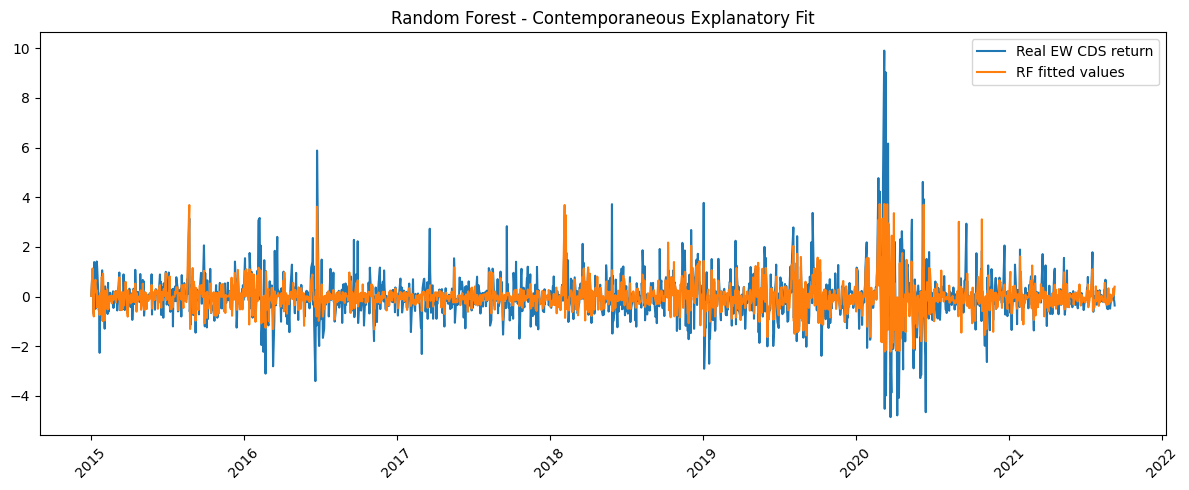

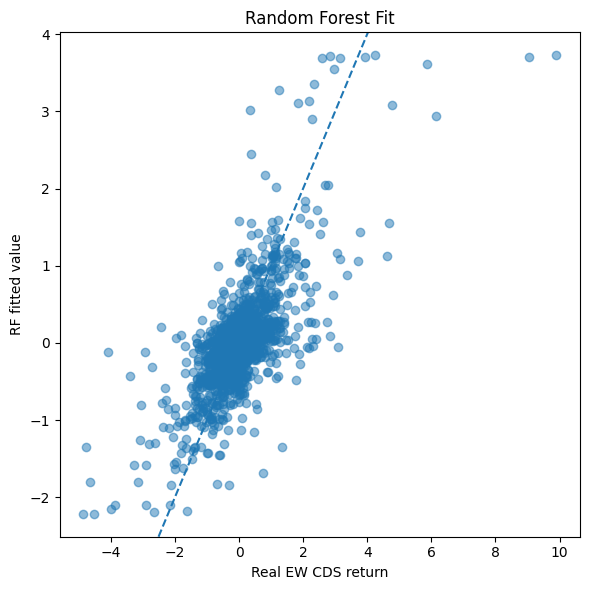

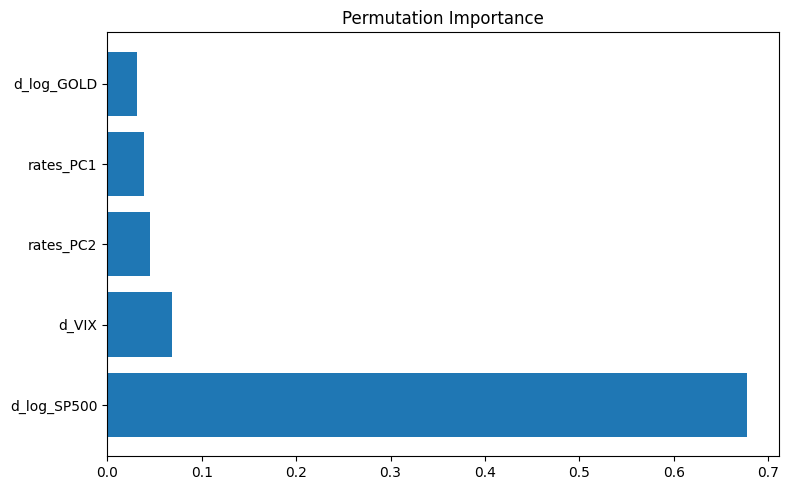

,Variable,Importance
2,d_log_SP500,0.6996
3,d_VIX,0.1478
1,rates_PC2,0.0569
0,rates_PC1,0.0486
4,d_log_GOLD,0.0472


,Variable,Importance
2,d_log_SP500,0.6775
3,d_VIX,0.0685
1,rates_PC2,0.0455
0,rates_PC1,0.0391
4,d_log_GOLD,0.0312


In [81]:
data_rf = panel_US_final.copy()
data_rf = data_rf.sort_values(["Date", "Company"])


ew_data = (
    data_rf
    .groupby("Date")
    .agg(
        EW_CDS_RET=("d_log_CDS5", "mean"),
        rates_PC1=("rates_PC1", "first"),
        rates_PC2=("rates_PC2", "first"),
        d_log_SP500=("d_log_SP500", "first"),
        d_VIX=("d_VIX", "first"),
        d_log_GOLD=("d_log_GOLD", "first")
    )
    .reset_index()
    .dropna()
)


features = [
    "rates_PC1",
    "rates_PC2",
    "d_log_SP500",
    "d_VIX",
    "d_log_GOLD"
]

X = ew_data[features]
y = ew_data["EW_CDS_RET"]


rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

pred = rf.predict(X)
r2 = r2_score(y, pred)
corr = np.corrcoef(y, pred)[0, 1]

print("\n" + "="*60)
print("RANDOM FOREST EXPLANATORY MODEL")
print("="*60)
print(f"In-sample R²          : {r2:.4f}")
print(f"Correlation          : {corr:.4f}")
print("="*60)

importance_rf = pd.DataFrame({
    "Variable": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nRF FEATURE IMPORTANCE")
print(importance_rf)

perm = permutation_importance(
    rf,
    X,
    y,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_perm = pd.DataFrame({
    "Variable": features,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

print("\nPERMUTATION IMPORTANCE")
print(importance_perm)

plt.figure(figsize=(12,5))
plt.plot(ew_data["Date"], y, label="Real EW CDS return")
plt.plot(ew_data["Date"], pred, label="RF fitted values")
plt.legend()
plt.title("Random Forest - Contemporaneous Explanatory Fit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y, pred, alpha=0.5)
plt.axline((0,0), slope=1, linestyle="--")
plt.xlabel("Real EW CDS return")
plt.ylabel("RF fitted value")
plt.title("Random Forest Fit")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.barh(
    importance_perm["Variable"],
    importance_perm["Importance"]
)
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()


display(importance_rf)
display(importance_perm)

At the end of this brief analysis we note that the random forest finds the same features in the index as the linear regression with the single banks, with a little improvement in the performance.

From now it is natural to try our models in terms of forecasting.

## Forecasting
### Forecasting with AR(1) - GARCH - X
Now we try to forecast the future index return realizations using the macro regressors with a lag 1 in the dependent variable.

                          AR-X - GARCH Model Results                          
Dep. Variable:                      y   R-squared:                       0.004
Mean Model:                      AR-X   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3733.26
Distribution:                  Normal   AIC:                           7486.52
Method:            Maximum Likelihood   BIC:                           7540.10
                                        No. Observations:                 1569
Date:                Tue, Jun 16 2026   Df Residuals:                     1562
Time:                        09:56:54   Df Model:                            7
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const         -0.1423  6.714e-02     -2.120  3.404e-02 [ -0.2

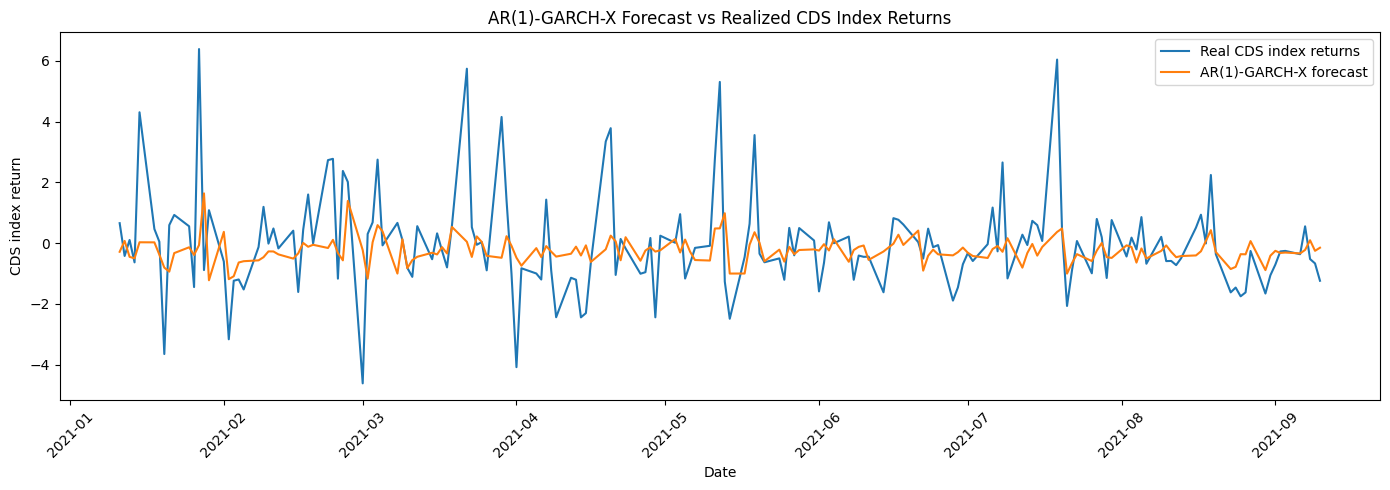

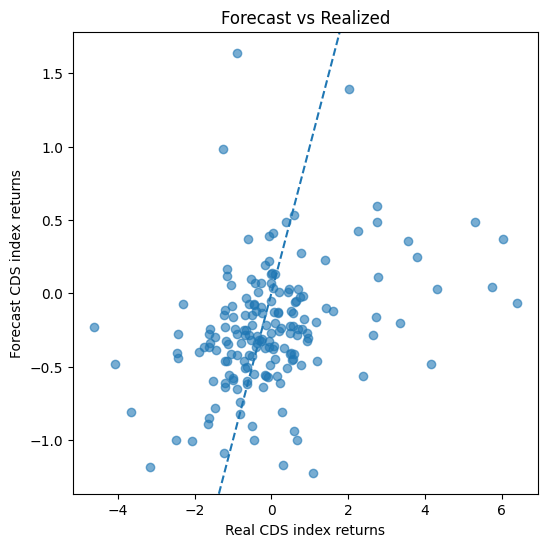

,Date,Real_y,Forecast_y,Forecast_volatility,Error
0,2021-01-11,0.6584,-0.2843,2.3129,0.9426
1,2021-01-12,-0.4216,0.0739,2.1428,-0.4955
2,2021-01-13,0.1046,-0.4507,2.0122,0.5552
3,2021-01-14,-0.6322,-0.4996,1.8943,-0.1326
4,2021-01-15,4.3102,0.0291,2.7507,4.2811


In [82]:
df_garch = cds_index_lvl[["Date", "EW_CDS_RET"]].copy()

df_garch = df_garch.merge(
    macro[["Date", "d_VIX", "d_log_GOLD"]],
    on="Date",
    how="inner"
)

df_garch = df_garch.merge(
    sp500_tmp[["Date", "d_log_SP500"]],
    on="Date",
    how="inner"
)

rates_pc = (
    panel_US_final[["Date", "rates_PC1", "rates_PC2"]]
    .drop_duplicates(subset="Date")
    .copy()
)

df_garch = df_garch.merge(
    rates_pc,
    on="Date",
    how="inner"
)

df_garch = df_garch.sort_values("Date").dropna().reset_index(drop=True)

y_arr = 100 * df_garch["EW_CDS_RET"].values

X_raw = df_garch[
    ["d_VIX", "d_log_SP500", "d_log_GOLD", "rates_PC1", "rates_PC2"]
].values

y_model = y_arr[1:]
X_lag1 = X_raw[:-1, :]

split = int(len(y_model) * 0.9)

y_train, y_test = y_model[:split], y_model[split:]
X_train, X_test = X_lag1[:split], X_lag1[split:]

model = arch_model(
    y_model,
    mean="ARX",
    lags=1,
    x=X_lag1,
    vol="GARCH",
    p=1,
    q=1,
    rescale=False
)

res = model.fit(
    last_obs=split,
    update_freq=0,
    disp="off"
)

print(res.summary())

x_forecast = {
    f"x{i}": X_test[:, i].reshape(-1, 1)
    for i in range(X_test.shape[1])
}

forecast = res.forecast(
    horizon=1,
    start=split,
    x=x_forecast,
    reindex=False
)

pred_mean = forecast.mean.iloc[:, 0].values
pred_var = forecast.variance.iloc[:, 0].values
pred_vol = np.sqrt(pred_var)

n = min(len(y_test), len(pred_mean))

comparison_garchx_pc = pd.DataFrame({
    "Date": df_garch["Date"].iloc[-n:].values,
    "Real_y": y_test[:n],
    "Forecast_y": pred_mean[:n],
    "Forecast_volatility": pred_vol[:n],
    "Error": y_test[:n] - pred_mean[:n]
})


y_true = comparison_garchx_pc["Real_y"].values
y_pred = comparison_garchx_pc["Forecast_y"].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]
directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

print("\n" + "="*60)
print("AR(1)-GARCH-X WITH RATES PCs - OUT-OF-SAMPLE PERFORMANCE")
print("="*60)
print(f"MAE                 : {mae:.4f}")
print(f"MSE                 : {mse:.4f}")
print(f"RMSE                : {rmse:.4f}")
print(f"R²                  : {r2:.4f}")
print(f"Correlation         : {corr:.4f}")
print(f"Directional Acc (%) : {directional_accuracy:.2f}")
print("="*60)


plt.figure(figsize=(14,5))
plt.plot(comparison_garchx_pc["Date"], comparison_garchx_pc["Real_y"], label="Real CDS index returns")
plt.plot(comparison_garchx_pc["Date"], comparison_garchx_pc["Forecast_y"], label="AR(1)-GARCH-X forecast")
plt.legend()
plt.title("AR(1)-GARCH-X Forecast vs Realized CDS Index Returns")
plt.xlabel("Date")
plt.ylabel("CDS index return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(comparison_garchx_pc["Real_y"], comparison_garchx_pc["Forecast_y"], alpha=0.6)
plt.axline((0, 0), slope=1, linestyle="--")
plt.xlabel("Real CDS index returns")
plt.ylabel("Forecast CDS index returns")
plt.title("Forecast vs Realized")
plt.show()

comparison_garchx_pc.head()


GARCH-X VOLATILITY FORECAST PERFORMANCE
Correlation (variance vs squared returns): 0.6433
MSE variance forecast                    : 28.7342
RMSE variance forecast                   : 5.3604


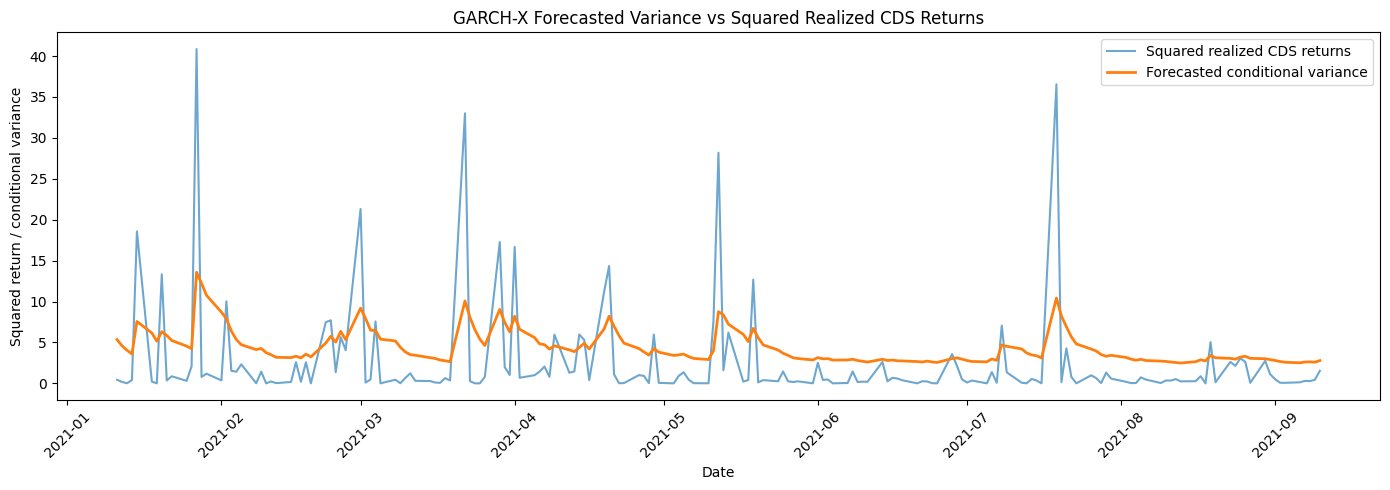

,Date,Squared_realized_return,Forecast_variance,Forecast_volatility
0,2021-01-11,0.4334,5.3496,2.3129
1,2021-01-12,0.1777,4.5917,2.1428
2,2021-01-13,0.0109,4.0491,2.0122
3,2021-01-14,0.3996,3.5884,1.8943
4,2021-01-15,18.5777,7.5664,2.7507


In [83]:
# ============================================================
# VOLATILITY FORECAST: GARCH-X CONDITIONAL VARIANCE
# ============================================================

vol_forecast = res.forecast(
    horizon=1,
    start=split,
    x=x_forecast,
    reindex=False
)

forecast_variance = vol_forecast.variance.iloc[:, 0].values
forecast_volatility = np.sqrt(forecast_variance)

n_vol = min(len(y_test), len(forecast_variance))

volatility_forecast_garchx_pc = pd.DataFrame({
    "Date": df_garch["Date"].iloc[1 + split : 1 + split + n_vol].values,
    "Squared_realized_return": y_test[:n_vol] ** 2,
    "Forecast_variance": forecast_variance[:n_vol],
    "Forecast_volatility": forecast_volatility[:n_vol]
})

vol_corr = np.corrcoef(
    volatility_forecast_garchx_pc["Squared_realized_return"],
    volatility_forecast_garchx_pc["Forecast_variance"]
)[0, 1]

vol_mse = mean_squared_error(
    volatility_forecast_garchx_pc["Squared_realized_return"],
    volatility_forecast_garchx_pc["Forecast_variance"]
)
vol_rmse = np.sqrt(vol_mse)

print("\n" + "="*60)
print("GARCH-X VOLATILITY FORECAST PERFORMANCE")
print("="*60)
print(f"Correlation (variance vs squared returns): {vol_corr:.4f}")
print(f"MSE variance forecast                    : {vol_mse:.4f}")
print(f"RMSE variance forecast                   : {vol_rmse:.4f}")
print("="*60)

plt.figure(figsize=(14, 5))
plt.plot(
    volatility_forecast_garchx_pc["Date"],
    volatility_forecast_garchx_pc["Squared_realized_return"],
    label="Squared realized CDS returns",
    alpha=0.65
)
plt.plot(
    volatility_forecast_garchx_pc["Date"],
    volatility_forecast_garchx_pc["Forecast_variance"],
    label="Forecasted conditional variance",
    linewidth=2
)
plt.title("GARCH-X Forecasted Variance vs Squared Realized CDS Returns")
plt.xlabel("Date")
plt.ylabel("Squared return / conditional variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

volatility_forecast_garchx_pc.head()


We found that this model is in a little way capable of sensing the sign of the realizations in 63% of the cases, but without any ability to find the intensity of the realizations. The R2 near to 0 is completely expectable due to the intrinsic imprevedibility of the returns.

We now replicate the same modelling workflow for European banks, using European rates and EUROSTOXX.

## EU Dataset Analysis

### Linear Regression EU

In [84]:
df = panel_EU_final.copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index(["Ticker", "Date"])

y = df["d_log_CDS5"]

X = df[
    [
        "eu_rates_PC1",
        "eu_rates_PC2",
        "d_log_EUROSTOXX",
        "d_VIX",
        "d_log_GOLD"
    ]
]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True
)

res = model.fit(cov_type="clustered", cluster_entity=True)

res

Dep. Variable:,d_log_CDS5,R-squared:,0.3880
Estimator:,PanelOLS,R-squared (Between):,0.3808
No. Observations:,12184,R-squared (Within):,0.3880
Date:,"Tue, Jun 16 2026",R-squared (Overall):,0.3880
Time:,09:56:55,Log-likelihood,-1.43e+04
Cov. Estimator:,Clustered,,
,,F-statistic:,1543.2
Entities:,7,P-value,0.0000
Avg Obs:,1740.6,Distribution:,"F(5,12172)"
Min Obs:,1708.0,,
Max Obs:,1746.0,F-statistic (robust):,3699.4


In [85]:
# Random effects panel regression - EU

random_effects_model_EU = RandomEffects(y, X)
random_effects_res_EU = random_effects_model_EU.fit(
    cov_type="clustered",
    cluster_entity=True
)

random_effects_res_EU


Dep. Variable:,d_log_CDS5,R-squared:,0.3880
Estimator:,RandomEffects,R-squared (Between):,0.3809
No. Observations:,12184,R-squared (Within):,0.3880
Date:,"Tue, Jun 16 2026",R-squared (Overall):,0.3880
Time:,09:56:55,Log-likelihood,-1.43e+04
Cov. Estimator:,Clustered,,
,,F-statistic:,1544.0
Entities:,7,P-value,0.0000
Avg Obs:,1740.6,Distribution:,"F(5,12178)"
Min Obs:,1708.0,,
Max Obs:,1746.0,F-statistic (robust):,3739.2


In [86]:
# Hausman test - EU

def hausman_test(fixed_res, random_res, area_label):
    common_params = fixed_res.params.index.intersection(random_res.params.index)
    common_params = [
        param for param in common_params
        if param.lower() not in {"const", "intercept"}
    ]

    beta_diff = fixed_res.params.loc[common_params] - random_res.params.loc[common_params]
    cov_diff = fixed_res.cov.loc[common_params, common_params] - random_res.cov.loc[common_params, common_params]

    diff_values = beta_diff.to_numpy()
    cov_diff_values = cov_diff.to_numpy()
    statistic = float(diff_values.T @ np.linalg.pinv(cov_diff_values) @ diff_values)
    degrees_freedom = len(common_params)
    p_value = 1 - chi2.cdf(statistic, degrees_freedom)

    return pd.DataFrame({
        "area": [area_label],
        "chi2_stat": [statistic],
        "df": [degrees_freedom],
        "p_value": [p_value],
        "decision_5pct": [
            "Reject random effects" if p_value < 0.05 else "Do not reject random effects"
        ]
    })

fixed_effects_res_EU_hausman = model.fit(cov_type="unadjusted")
random_effects_res_EU_hausman = random_effects_model_EU.fit(cov_type="unadjusted")

hausman_EU = hausman_test(
    fixed_effects_res_EU_hausman,
    random_effects_res_EU_hausman,
    "EU"
)

hausman_EU


,area,chi2_stat,df,p_value,decision_5pct
0,EU,0.0049,5,1.0000,Do not reject random effects


In [87]:
residuals = res.resids.dropna()

X = df[[
    "eu_rates_PC1",
        "eu_rates_PC2",
        "d_log_EUROSTOXX",
        "d_VIX",
        "d_log_GOLD"
]].loc[residuals.index]

aux_X = sm.add_constant(X)

aux_model = sm.OLS(residuals**2, aux_X).fit()

bp_stat = aux_model.rsquared * len(residuals)

dw_stat = durbin_watson(residuals)

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

diagnostics = pd.DataFrame({
    "Test": ["Breusch-Pagan (proxy)", "Durbin-Watson", "Jarque-Bera"],
    "Statistic": [bp_stat, dw_stat, jb_stat],
    "p-value / interpretation": ["N/A", "N/A", jb_pvalue],
    "Extra": ["heteroskedasticity proxy", "autocorrelation", f"skew={skew:.3f}, kurt={kurtosis:.3f}"]
})

diagnostics

,Test,Statistic,p-value / interpretation,Extra
0,Breusch-Pagan (proxy),29.5052,N/A,heteroskedasticity proxy
1,Durbin-Watson,1.7572,N/A,autocorrelation
2,Jarque-Bera,243843.2908,0.0000,"skew=-0.358, kurt=24.905"


We notice that now in the EU case all the variables are significant in the regression, but as before the main drivers are the VIX and the EUROSTOXX, the equivalent equity index. 
As the previous case the test on the residual show Heteroskedasticity and non-gaussianity

### ARCH test EU

Before estimating GARCH, we test whether the equally weighted EU CDS returns show ARCH effects.

In [88]:
cds_index_lvl_EU = (
    cds_EU_PX5.groupby("Date")["PX5"]
    .mean()
    .reset_index()
    .rename(columns={"PX5": "EW_CDS_LEVEL"})
)

cds_index_lvl_EU["EW_CDS_RET"] = np.log(cds_index_lvl_EU["EW_CDS_LEVEL"]).diff()
eu_arch_residuals = cds_index_lvl_EU["EW_CDS_RET"].dropna()
eu_arch_residuals = eu_arch_residuals - eu_arch_residuals.mean()

arch_test_EU = arch_lm_test(eu_arch_residuals, lags=arch_lags, label="EU EW CDS returns")
arch_test_EU

,series,lags,observations,TR2_statistic,p_value,decision_5pct
0,EU EW CDS returns,10,1736,268.1449,0.0000,ARCH effects present


### GARCH - X EU

As in the US case, we build an equally weighted CDS index for the European banks and use European market regressors.

In [89]:
cds_index_lvl_EU = (
    cds_EU_PX5.groupby("Date")["PX5"]
    .mean()
    .reset_index()
    .rename(columns={"PX5": "EW_CDS_LEVEL"})
)

cds_index_lvl_EU["EW_CDS_RET"] = np.log(cds_index_lvl_EU["EW_CDS_LEVEL"]).diff()

df_garchx_EU = cds_index_lvl_EU.merge(
    macro_EU[["Date", "d_VIX", "d_log_GOLD", "d_log_EUROSTOXX"]],
    on="Date",
    how="inner"
)

df_garchx_EU = df_garchx_EU.dropna().reset_index(drop=True)
y_EU = 100 * df_garchx_EU["EW_CDS_RET"]
X_EU = df_garchx_EU[["d_VIX", "d_log_EUROSTOXX", "d_log_GOLD"]].values

model_EU = arch_model(
    y_EU,
    mean="ARX",
    lags=0,
    x=X_EU,
    vol="GARCH",
    p=1,
    q=1,
    rescale=False
)

res_EU_garchx = model_EU.fit(update_freq=0)

print(res_EU_garchx.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 3937.9139280025174
            Iterations: 20
            Function evaluations: 173
            Gradient evaluations: 20
                          AR-X - GARCH Model Results                          
Dep. Variable:             EW_CDS_RET   R-squared:                       0.471
Mean Model:                      AR-X   Adj. R-squared:                  0.470
Vol Model:                      GARCH   Log-Likelihood:               -3937.91
Distribution:                  Normal   AIC:                           7889.83
Method:            Maximum Likelihood   BIC:                           7928.08
                                        No. Observations:                 1746
Date:                Tue, Jun 16 2026   Df Residuals:                     1742
Time:                        09:56:55   Df Model:                            4
                                  Mean Model                                  

We now try the same machine learning explanatory model on the European equally weighted CDS index.

### Random Forest EU


EU RANDOM FOREST EXPLANATORY MODEL
In-sample R2          : 0.5306
Correlation          : 0.7303

EU RF FEATURE IMPORTANCE
          Variable  Importance
2  d_log_EUROSTOXX      0.8876
3            d_VIX      0.0390
1     eu_rates_PC2      0.0281
4       d_log_GOLD      0.0226
0     eu_rates_PC1      0.0225

EU PERMUTATION IMPORTANCE
          Variable  Importance
2  d_log_EUROSTOXX      0.9428
3            d_VIX      0.0272
1     eu_rates_PC2      0.0219
0     eu_rates_PC1      0.0151
4       d_log_GOLD      0.0150


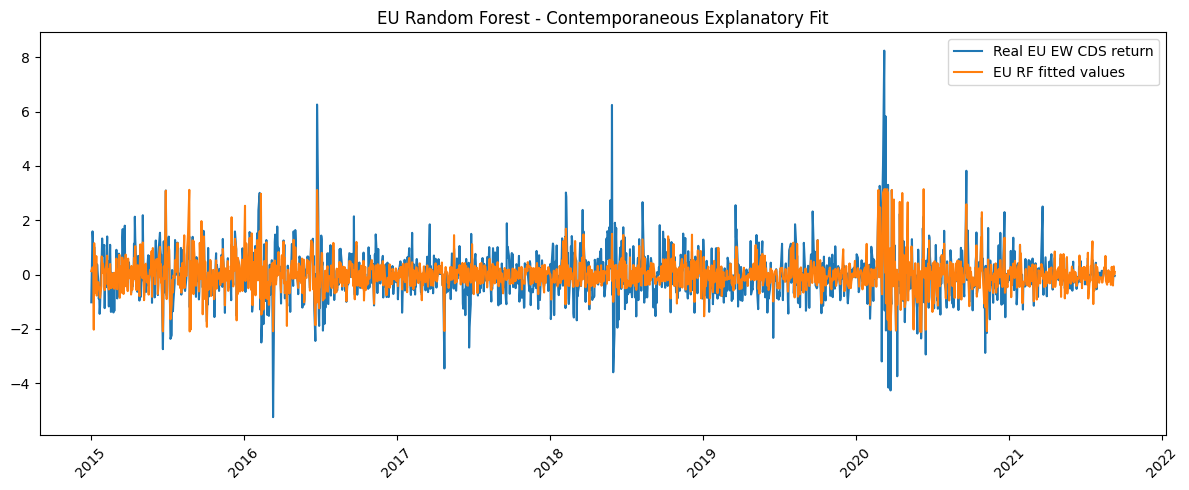

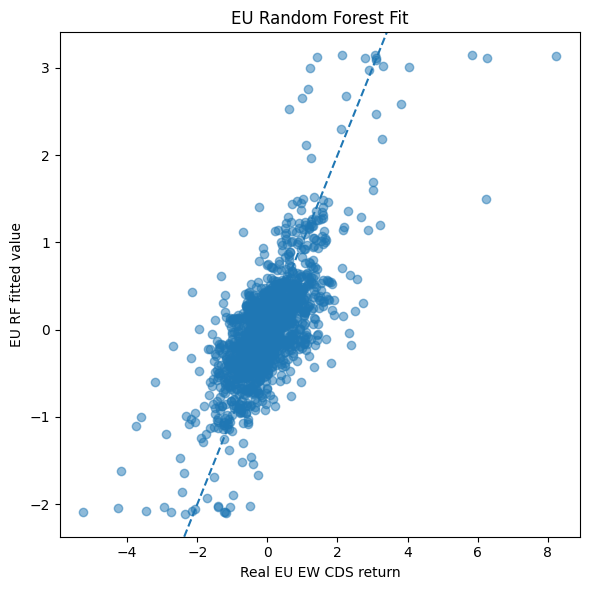

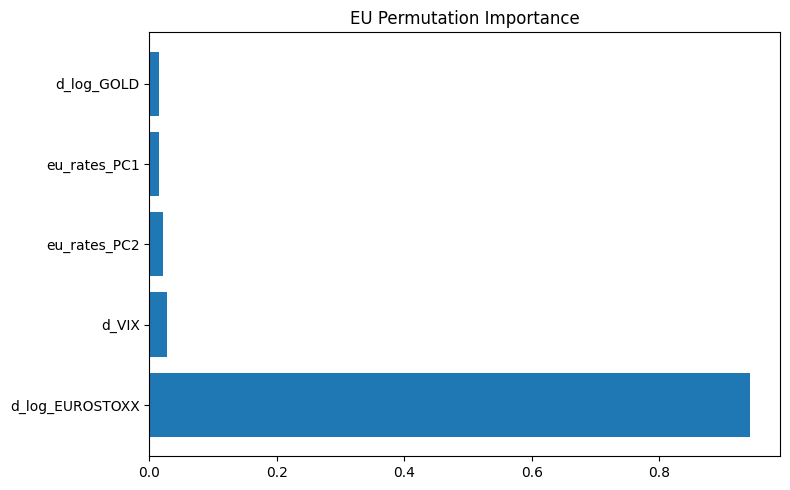

,Variable,Importance
2,d_log_EUROSTOXX,0.8876
3,d_VIX,0.0390
1,eu_rates_PC2,0.0281
4,d_log_GOLD,0.0226
0,eu_rates_PC1,0.0225


,Variable,Importance
2,d_log_EUROSTOXX,0.9428
3,d_VIX,0.0272
1,eu_rates_PC2,0.0219
0,eu_rates_PC1,0.0151
4,d_log_GOLD,0.0150


In [90]:
data_rf_EU = panel_EU_final.copy()
data_rf_EU = data_rf_EU.sort_values(["Date", "Company"])


ew_data_EU = (
    data_rf_EU
    .groupby("Date")
    .agg(
        EW_CDS_RET=("d_log_CDS5", "mean"),
        eu_rates_PC1=("eu_rates_PC1", "first"),
        eu_rates_PC2=("eu_rates_PC2", "first"),
        d_log_EUROSTOXX=("d_log_EUROSTOXX", "first"),
        d_VIX=("d_VIX", "first"),
        d_log_GOLD=("d_log_GOLD", "first")
    )
    .reset_index()
    .dropna()
)


features_EU = [
    "eu_rates_PC1",
    "eu_rates_PC2",
    "d_log_EUROSTOXX",
    "d_VIX",
    "d_log_GOLD"
]

X_EU = ew_data_EU[features_EU]
y_EU = ew_data_EU["EW_CDS_RET"]


rf_EU = RandomForestRegressor(
    n_estimators=1000,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_EU.fit(X_EU, y_EU)

pred_EU = rf_EU.predict(X_EU)
r2_EU = r2_score(y_EU, pred_EU)
corr_EU = np.corrcoef(y_EU, pred_EU)[0, 1]

print("\n" + "="*60)
print("EU RANDOM FOREST EXPLANATORY MODEL")
print("="*60)
print(f"In-sample R2          : {r2_EU:.4f}")
print(f"Correlation          : {corr_EU:.4f}")
print("="*60)

importance_rf_EU = pd.DataFrame({
    "Variable": features_EU,
    "Importance": rf_EU.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nEU RF FEATURE IMPORTANCE")
print(importance_rf_EU)

perm_EU = permutation_importance(
    rf_EU,
    X_EU,
    y_EU,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_perm_EU = pd.DataFrame({
    "Variable": features_EU,
    "Importance": perm_EU.importances_mean
}).sort_values("Importance", ascending=False)

print("\nEU PERMUTATION IMPORTANCE")
print(importance_perm_EU)

plt.figure(figsize=(12,5))
plt.plot(ew_data_EU["Date"], y_EU, label="Real EU EW CDS return")
plt.plot(ew_data_EU["Date"], pred_EU, label="EU RF fitted values")
plt.legend()
plt.title("EU Random Forest - Contemporaneous Explanatory Fit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y_EU, pred_EU, alpha=0.5)
plt.axline((0,0), slope=1, linestyle="--")
plt.xlabel("Real EU EW CDS return")
plt.ylabel("EU RF fitted value")
plt.title("EU Random Forest Fit")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.barh(
    importance_perm_EU["Variable"],
    importance_perm_EU["Importance"]
)
plt.title("EU Permutation Importance")
plt.tight_layout()
plt.show()


display(importance_rf_EU)
display(importance_perm_EU)

## Forecasting EU
### Forecasting with AR(1) - GARCH - X EU

We repeat the forecasting exercise with lagged European macro regressors, European rates PCs and EUROSTOXX.

                          AR-X - GARCH Model Results                          
Dep. Variable:                      y   R-squared:                       0.046
Mean Model:                      AR-X   Adj. R-squared:                  0.042
Vol Model:                      GARCH   Log-Likelihood:               -3978.92
Distribution:                  Normal   AIC:                           7977.83
Method:            Maximum Likelihood   BIC:                           8031.41
                                        No. Observations:                 1569
Date:                Tue, Jun 16 2026   Df Residuals:                     1562
Time:                        09:57:03   Df Model:                            7
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const         -0.1137  7.760e-02     -1.465      0.143  [ -0.

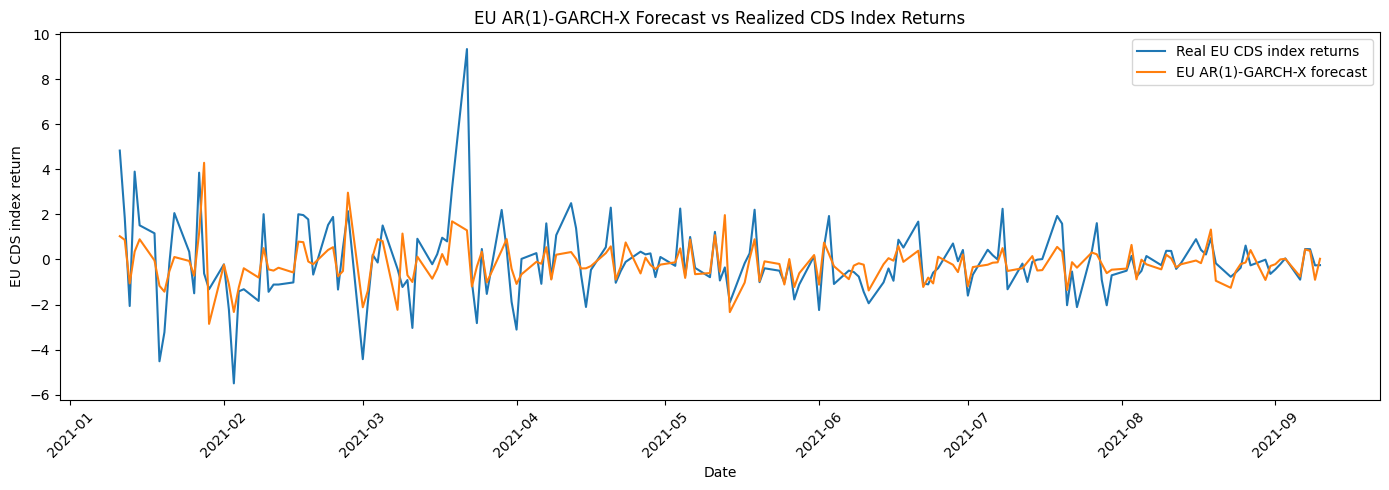

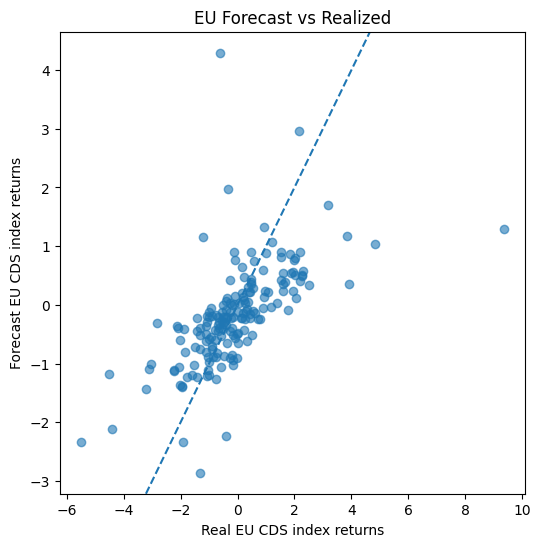

,Date,Real_y,Forecast_y,Forecast_volatility,Error
0,2021-01-11,4.8387,1.0334,3.0003,3.8052
1,2021-01-12,1.8555,0.8723,2.7981,0.9831
2,2021-01-13,-2.0670,-1.0645,2.7347,-1.0025
3,2021-01-14,3.9041,0.3528,3.2180,3.5512
4,2021-01-15,1.5169,0.8978,2.9724,0.6191


In [91]:
df_garch_EU = cds_index_lvl_EU[["Date", "EW_CDS_RET"]].copy()

df_garch_EU = df_garch_EU.merge(
    macro_EU[["Date", "d_VIX", "d_log_GOLD", "d_log_EUROSTOXX"]],
    on="Date",
    how="inner"
)

eu_rates_pc = (
    panel_EU_final[["Date", "eu_rates_PC1", "eu_rates_PC2"]]
    .drop_duplicates(subset="Date")
    .copy()
)

df_garch_EU = df_garch_EU.merge(
    eu_rates_pc,
    on="Date",
    how="inner"
)

df_garch_EU = df_garch_EU.sort_values("Date").dropna().reset_index(drop=True)

y_arr_EU = 100 * df_garch_EU["EW_CDS_RET"].values

X_raw_EU = df_garch_EU[
    ["d_VIX", "d_log_EUROSTOXX", "d_log_GOLD", "eu_rates_PC1", "eu_rates_PC2"]
].values

y_model_EU = y_arr_EU[1:]
X_lag1_EU = X_raw_EU[:-1, :]

split_EU = int(len(y_model_EU) * 0.9)

y_train_EU, y_test_EU = y_model_EU[:split_EU], y_model_EU[split_EU:]
X_train_EU, X_test_EU = X_lag1_EU[:split_EU], X_lag1_EU[split_EU:]

model_EU = arch_model(
    y_model_EU,
    mean="ARX",
    lags=1,
    x=X_lag1_EU,
    vol="GARCH",
    p=1,
    q=1,
    rescale=False
)

res_EU_forecast = model_EU.fit(
    last_obs=split_EU,
    update_freq=0,
    disp="off"
)

print(res_EU_forecast.summary())

x_forecast_EU = {
    f"x{i}": X_test_EU[:, i].reshape(-1, 1)
    for i in range(X_test_EU.shape[1])
}

forecast_EU = res_EU_forecast.forecast(
    horizon=1,
    start=split_EU,
    x=x_forecast_EU,
    reindex=False
)

pred_mean_EU = forecast_EU.mean.iloc[:, 0].values
pred_var_EU = forecast_EU.variance.iloc[:, 0].values
pred_vol_EU = np.sqrt(pred_var_EU)

n_EU = min(len(y_test_EU), len(pred_mean_EU))

comparison_garchx_eu_pc = pd.DataFrame({
    "Date": df_garch_EU["Date"].iloc[-n_EU:].values,
    "Real_y": y_test_EU[:n_EU],
    "Forecast_y": pred_mean_EU[:n_EU],
    "Forecast_volatility": pred_vol_EU[:n_EU],
    "Error": y_test_EU[:n_EU] - pred_mean_EU[:n_EU]
})


y_true_EU = comparison_garchx_eu_pc["Real_y"].values
y_pred_EU = comparison_garchx_eu_pc["Forecast_y"].values

mae_EU = mean_absolute_error(y_true_EU, y_pred_EU)
mse_EU = mean_squared_error(y_true_EU, y_pred_EU)
rmse_EU = np.sqrt(mse_EU)
r2_EU = r2_score(y_true_EU, y_pred_EU)
corr_EU = np.corrcoef(y_true_EU, y_pred_EU)[0, 1]
directional_accuracy_EU = np.mean(np.sign(y_true_EU) == np.sign(y_pred_EU)) * 100

print("\n" + "="*60)
print("EU AR(1)-GARCH-X WITH EU RATES PCs - OUT-OF-SAMPLE PERFORMANCE")
print("="*60)
print(f"MAE                 : {mae_EU:.4f}")
print(f"MSE                 : {mse_EU:.4f}")
print(f"RMSE                : {rmse_EU:.4f}")
print(f"R2                  : {r2_EU:.4f}")
print(f"Correlation         : {corr_EU:.4f}")
print(f"Directional Acc (%) : {directional_accuracy_EU:.2f}")
print("="*60)


plt.figure(figsize=(14,5))
plt.plot(comparison_garchx_eu_pc["Date"], comparison_garchx_eu_pc["Real_y"], label="Real EU CDS index returns")
plt.plot(comparison_garchx_eu_pc["Date"], comparison_garchx_eu_pc["Forecast_y"], label="EU AR(1)-GARCH-X forecast")
plt.legend()
plt.title("EU AR(1)-GARCH-X Forecast vs Realized CDS Index Returns")
plt.xlabel("Date")
plt.ylabel("EU CDS index return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(comparison_garchx_eu_pc["Real_y"], comparison_garchx_eu_pc["Forecast_y"], alpha=0.6)
plt.axline((0, 0), slope=1, linestyle="--")
plt.xlabel("Real EU CDS index returns")
plt.ylabel("Forecast EU CDS index returns")
plt.title("EU Forecast vs Realized")
plt.show()

comparison_garchx_eu_pc.head()


EU GARCH-X VOLATILITY FORECAST PERFORMANCE
Correlation (variance vs squared returns): 0.6007
MSE variance forecast                    : 53.1811
RMSE variance forecast                   : 7.2925


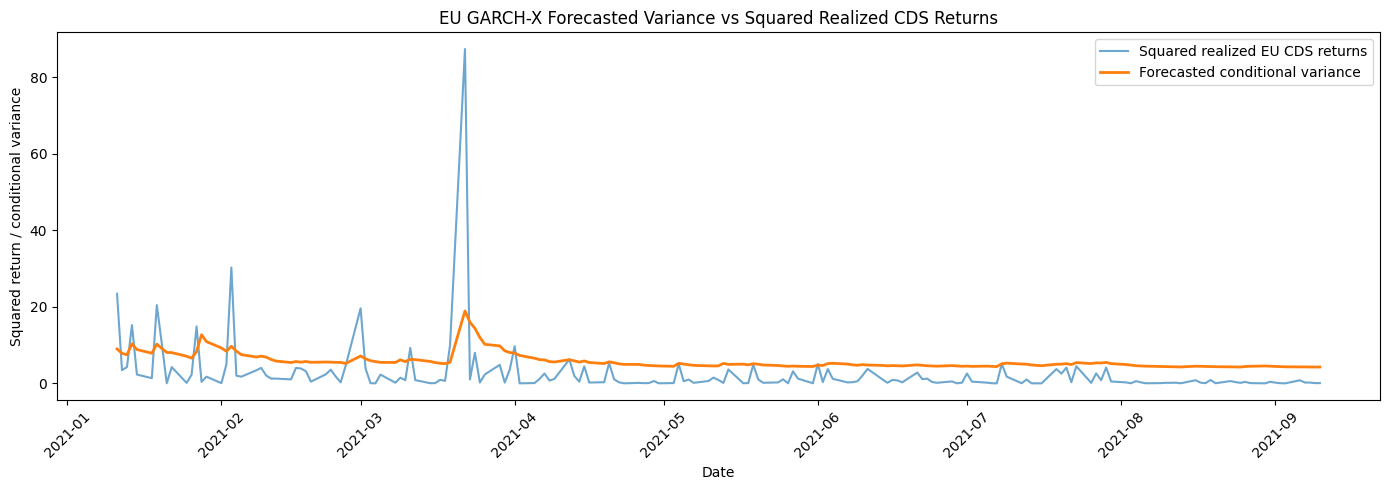

,Date,Squared_realized_return,Forecast_variance,Forecast_volatility
0,2021-01-11,23.4127,9.0020,3.0003
1,2021-01-12,3.4428,7.8296,2.7981
2,2021-01-13,4.2726,7.4785,2.7347
3,2021-01-14,15.2419,10.3553,3.2180
4,2021-01-15,2.3010,8.8349,2.9724


In [92]:
# ============================================================
# EU VOLATILITY FORECAST: GARCH-X CONDITIONAL VARIANCE
# ============================================================

eu_vol_forecast = res_EU_forecast.forecast(
    horizon=1,
    start=split_EU,
    x=x_forecast_EU,
    reindex=False
)

forecast_variance_EU = eu_vol_forecast.variance.iloc[:, 0].values
forecast_volatility_EU = np.sqrt(forecast_variance_EU)

n_vol_EU = min(len(y_test_EU), len(forecast_variance_EU))

volatility_forecast_garchx_eu_pc = pd.DataFrame({
    "Date": df_garch_EU["Date"].iloc[1 + split_EU : 1 + split_EU + n_vol_EU].values,
    "Squared_realized_return": y_test_EU[:n_vol_EU] ** 2,
    "Forecast_variance": forecast_variance_EU[:n_vol_EU],
    "Forecast_volatility": forecast_volatility_EU[:n_vol_EU]
})

vol_corr_EU = np.corrcoef(
    volatility_forecast_garchx_eu_pc["Squared_realized_return"],
    volatility_forecast_garchx_eu_pc["Forecast_variance"]
)[0, 1]

vol_mse_EU = mean_squared_error(
    volatility_forecast_garchx_eu_pc["Squared_realized_return"],
    volatility_forecast_garchx_eu_pc["Forecast_variance"]
)
vol_rmse_EU = np.sqrt(vol_mse_EU)

print("\n" + "="*60)
print("EU GARCH-X VOLATILITY FORECAST PERFORMANCE")
print("="*60)
print(f"Correlation (variance vs squared returns): {vol_corr_EU:.4f}")
print(f"MSE variance forecast                    : {vol_mse_EU:.4f}")
print(f"RMSE variance forecast                   : {vol_rmse_EU:.4f}")
print("="*60)

plt.figure(figsize=(14, 5))
plt.plot(
    volatility_forecast_garchx_eu_pc["Date"],
    volatility_forecast_garchx_eu_pc["Squared_realized_return"],
    label="Squared realized EU CDS returns",
    alpha=0.65
)
plt.plot(
    volatility_forecast_garchx_eu_pc["Date"],
    volatility_forecast_garchx_eu_pc["Forecast_variance"],
    label="Forecasted conditional variance",
    linewidth=2
)
plt.title("EU GARCH-X Forecasted Variance vs Squared Realized CDS Returns")
plt.xlabel("Date")
plt.ylabel("Squared return / conditional variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

volatility_forecast_garchx_eu_pc.head()
